# Strategy Engine

Runs all trading strategies with compounding money across trades,
transaction costs, optimal stopping theory, and strategy switching.

## Strategies compared
| Strategy | Description |
|----------|-------------|
| S&P 500 (SPY) | Passive benchmark |
| Buy & Hold | Equal weight all tickers, never sell |
| Sector Rotation | Weekly rotation into best-buzz sector |
| Position Trader | 21-day holds on high-conviction signals |
| Best Trade/Month | Optimal stopping: best signal each month |
| Strategy Switcher | Uses best strategy per market regime |

## Money compounds across trades — profits from one trade fund the next.
Between trades: money sits in sector rotation strategy (best performer so far).

---
## 0. Install

In [1]:
# !pip install pandas requests python-dotenv scipy matplotlib

---
## 1. Configuration & Load

In [2]:
import os, io, requests, warnings, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv
load_dotenv()

GITHUB_REPO   = 'annhmartin/dataviz-historical-stocks-AnnetteMartin'
GITHUB_TOKEN  = os.environ.get('GITHUB_TOKEN', None)
OUTPUT_PREFIX = 'stock_tracking/sentiment_outputs'
CORR_PREFIX   = 'stock_tracking/correlation_outputs'
STOCKS_PREFIX = 'stock_tracking/stocks'
STRAT_PREFIX  = 'stock_tracking/strategy_outputs'

ANALYSIS_START      = '2015-01-01'
ANALYSIS_END        = datetime.now(timezone.utc).strftime('%Y-%m-%d')
STARTING_CASH       = 10000   # starting portfolio value
SENTIMENT_THRESHOLD = 0.05
HOLD_DAYS           = 21      # position trader hold period
SENT_THRESHOLD      = 0.4     # high-conviction signal threshold
MIN_STORIES         = 1

# Transaction costs
COMMISSION_PER_TRADE = 0.0     # most brokers are now $0 commission
SPREAD_PCT           = 0.001   # 0.1% bid-ask spread per trade
TOTAL_COST_PER_TRADE = COMMISSION_PER_TRADE + SPREAD_PCT

# Sector definitions (refined)
SECTORS = {
    'AI Accelerators'      : ['NVDA','AMD'],
    'Semiconductor Supply' : ['TSM','INTC','QCOM'],
    'Big Tech'             : ['GOOGL','MSFT','AAPL','META'],
    'Cloud / SaaS'         : ['AMZN','SNOW','DDOG','CRM','NOW','MDB'],
    'Cybersecurity'        : ['CRWD','PANW','OKTA'],
    'Enterprise AI'        : ['PLTR'],
    'Macro Risk'           : ['COIN','TSLA'],
    'Portfolio'            : ['INCY','KGC','NVO','PM','WPM'],
    'Consumer Tech'        : ['NFLX','SPOT','PINS'],
    'Enterprise Fintech'   : ['PYPL'],
}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'axes.grid': True,
    'grid.color': '#e8e8e8', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
})

def load_csv(path, token=None):
    url = f'https://raw.githubusercontent.com/{GITHUB_REPO}/main/{path}'
    headers = {'Authorization': f'Bearer {token}'} if token else {}
    resp = requests.get(url, headers=headers, timeout=60)
    if resp.status_code == 404: raise FileNotFoundError(path)
    resp.raise_for_status()
    content = resp.text.strip()
    if not content: return pd.DataFrame()
    return pd.read_csv(io.StringIO(content), low_memory=False)

def push_csv(df, path, token, msg=None):
    import base64, time
    GITHUB_API = 'https://api.github.com'
    if msg is None: msg = f'Update {path} - {len(df):,} rows'
    buf = io.StringIO(); df.to_csv(buf, index=False)
    encoded = base64.b64encode(buf.getvalue().encode()).decode()
    url = f'{GITHUB_API}/repos/{GITHUB_REPO}/contents/{path}'
    headers = {'Authorization': f'Bearer {token}',
               'Accept': 'application/vnd.github+json',
               'X-GitHub-Api-Version': '2022-11-28'}
    check = requests.get(url, headers=headers, timeout=15)
    sha = check.json().get('sha') if check.status_code == 200 else None
    payload = {'message': msg, 'content': encoded}
    if sha: payload['sha'] = sha
    resp = requests.put(url, headers=headers, json=payload, timeout=120)
    if resp.status_code in (200,201): print(f'  Saved {path}'); return True
    print(f'  FAILED: {resp.status_code}'); return False

# Load data
print('Loading signals and prices ...')
sig_frames = []
for year in range(int(ANALYSIS_START[:4]), int(ANALYSIS_END[:4])+1):
    for q in [1, 2, 3, 4]:
        try:
            df_y = load_csv(f'{OUTPUT_PREFIX}/daily_signals_{year}_Q{q}.csv', GITHUB_TOKEN)
            sig_frames.append(df_y)
        except FileNotFoundError: pass
# Fallback to yearly files
if not sig_frames:
    for year in range(int(ANALYSIS_START[:4]), int(ANALYSIS_END[:4])+1):
        try:
            df_y = load_csv(f'{OUTPUT_PREFIX}/daily_signals_{year}.csv', GITHUB_TOKEN)
            sig_frames.append(df_y)
        except FileNotFoundError: pass

if sig_frames:
    daily_signals = pd.concat(sig_frames, ignore_index=True)
    daily_signals['date'] = pd.to_datetime(daily_signals['date'])
    print(f'Signals: {len(daily_signals):,} rows, {daily_signals["ticker"].nunique()} tickers')
else:
    raise RuntimeError('Run A_sentiment_engine.ipynb first')

best_per_ticker = load_csv(f'{CORR_PREFIX}/best_per_ticker.csv', GITHUB_TOKEN)
all_tickers     = daily_signals['ticker'].unique().tolist()

# Load SPY
try:
    df_spy = load_csv(f'{STOCKS_PREFIX}/prices_SPY.csv', GITHUB_TOKEN)
    df_spy['Date'] = pd.to_datetime(df_spy['Date'])
    df_spy['daily_return'] = df_spy['Close'].pct_change(fill_method=None)
    df_spy = df_spy.set_index('Date').sort_index()
    SPY_AVAILABLE = True
    print(f'SPY: {len(df_spy):,} rows')
except FileNotFoundError:
    SPY_AVAILABLE = False
    print('SPY not found')

print('Configuration complete')

Loading signals and prices ...
Signals: 8,233,536 rows, 1952 tickers
SPY: 4,149 rows
Configuration complete


---
## 2. Load Prices for Strategy Tickers

In [3]:
# Load prices for all tickers we have signals for
print('Loading stock prices ...')
price_cache = {}
for i, ticker in enumerate(all_tickers):
    if i % 50 == 0: print(f'  {i}/{len(all_tickers)} ...', end='\r')
    try:
        df_p = load_csv(f'{STOCKS_PREFIX}/prices_{ticker}.csv', GITHUB_TOKEN)
        if df_p.empty or 'Close' not in df_p.columns: continue
        df_p['Date'] = pd.to_datetime(df_p['Date'])
        df_p['daily_return'] = df_p['Close'].pct_change(fill_method=None)
        price_cache[ticker] = df_p.set_index('Date').sort_index()
    except FileNotFoundError: pass

# Filter to quality tickers only — removes micro-caps and penny stocks
MIN_AVG_PRICE  = 10.0   # raised from 5 — filters out more penny stocks
MIN_SIGNAL_DAYS_STRAT = 100  # minimum signal days to trade a ticker

# Explicit blocklist — tickers confirmed to be bad signal matches
TRADE_BLOCKLIST = {
    'PSIX','FORM','HAPN','BPOPM','NSPR','CARE','SBFG','GLAD',
    'CBFV','LEDS','SHOE','WATT','TAOP','TTMI','DFLI','TONX',
    'BULL','DFNS','WLDS','XFOR','GRRR','CAPS','GWAV','FEAM',
    'GWAV','MASS','XOS','CDT','USOI','SERV','NTSK','RUBI',
    'GOVX','CETX','GMM','GLIBA','KIDZ','UPB','UPC','IIIV',
    'RDIB','SHIP','CAR','TWIN','HCSG','CENT','FIVE','NDAQ',
    'BIDU','PPLI','APPS','CARE','HCSG','CENT','PTRN','IRON',
    'ATGL','PARK','STEP','LYFT','FIGR','GTLB','EVER','ABNB',
}
MIN_SIGNAL_DAYS_STRAT = 100  # raised from 30 — eliminates micro-caps with sparse coverage

# Load coverage index to filter by signal days
try:
    df_coverage = load_csv(f'{OUTPUT_PREFIX}/sentiment_coverage.csv', GITHUB_TOKEN)
    coverage_lookup = dict(zip(df_coverage['ticker'], df_coverage['signal_days']))
    print(f'Coverage index loaded: {len(coverage_lookup)} tickers')
except FileNotFoundError:
    coverage_lookup = {}
    print('Coverage index not found — no signal day filter applied')

# Filter price cache
filtered_cache = {}
for ticker, df_p in price_cache.items():
    median_price = df_p['Close'].median()
    signal_days  = coverage_lookup.get(ticker, 0)
    if median_price >= MIN_AVG_PRICE and signal_days >= MIN_SIGNAL_DAYS_STRAT:
        filtered_cache[ticker] = df_p
price_cache = filtered_cache
priced_tickers = list(price_cache.keys())
print(f'\nAfter quality filter:')
print(f'  Loaded prices for {len(priced_tickers):,} tickers')
print(f'  Removed penny stocks (price < ${MIN_AVG_PRICE}) and low-coverage tickers')

# Build weekly price returns for sector rotation
weekly_ret_cache = {}
for ticker, df_p in price_cache.items():
    wr = (df_p['daily_return']
          .resample('W').sum()
          .rename(ticker))
    weekly_ret_cache[ticker] = wr
print('Weekly returns computed')

Loading stock prices ...
Coverage index loaded: 1952 tickers

After quality filter:
  Loaded prices for 174 tickers
  Removed penny stocks (price < $10.0) and low-coverage tickers
Weekly returns computed


---
## 3. Build Sector Rotation Baseline

Sector rotation runs from the very first week of data.
Money starts in sector rotation and stays there between active trades.

In [4]:
print('Building sector rotation baseline ...')

# Weekly sentiment per sector
sig_weekly = (
    daily_signals[daily_signals['norm_sentiment'].notna()]
    .assign(week=lambda d: d['date'].dt.to_period('W').dt.start_time)
    .groupby(['ticker','week'])['norm_sentiment'].mean()
    .reset_index()
)

SECTOR_QUALITY = {
    'AI Accelerators': 0.9, 'Semiconductor Supply': 0.9,
    'Big Tech': 1.1, 'Cloud / SaaS': 0.9, 'Cybersecurity': 0.9,
    'Enterprise AI': 1.0, 'Macro Risk': 1.1, 'Portfolio': 0.9,
    'Consumer Tech': 1.1, 'Enterprise Fintech': 0.8,
}
MIN_SECTOR_SIGNAL = 0.08

sector_sent_rows = []
for sector, tickers_s in SECTORS.items():
    quality   = SECTOR_QUALITY.get(sector, 1.0)
    available = [t for t in tickers_s if t in all_tickers]
    if not available: continue
    sub = sig_weekly[sig_weekly['ticker'].isin(available)]
    for week, grp in sub.groupby('week'):
        valid = grp['norm_sentiment'].dropna()
        if valid.empty: continue
        sector_sent_rows.append({
            'week': week, 'sector': sector,
            'sector_sent': valid.mean() * quality
        })

df_sec_sent   = pd.DataFrame(sector_sent_rows)
df_sec_sent['week'] = pd.to_datetime(df_sec_sent['week'])
sector_pivot  = df_sec_sent.pivot_table(index='week', columns='sector', values='sector_sent')
best_sector_w = sector_pivot.idxmax(axis=1)

# Run sector rotation from start
all_weeks   = sorted(set().union(*[wr.index for wr in weekly_ret_cache.values()]))
rot_cash    = STARTING_CASH
rot_hist    = []
rot_dates   = []
rot_trades  = 0

for week in all_weeks:
    week = pd.Timestamp(week)
    if week < pd.Timestamp(ANALYSIS_START): continue
    prior_w = best_sector_w.index[best_sector_w.index < week]
    if len(prior_w) == 0:
        rot_hist.append(rot_cash); rot_dates.append(week); continue
    chosen   = best_sector_w.loc[prior_w[-1]]
    best_sig = sector_pivot.loc[prior_w[-1], chosen] if prior_w[-1] in sector_pivot.index else 0
    if pd.isna(best_sig): best_sig = 0
    if best_sig >= MIN_SECTOR_SIGNAL:
        tickers_s = [t for t in SECTORS.get(chosen,[]) if t in weekly_ret_cache]
        if tickers_s:
            avg_ret = np.mean([weekly_ret_cache[t].get(week, 0) for t in tickers_s])
            if not pd.isna(avg_ret):
                rot_cash *= (1 + avg_ret - TOTAL_COST_PER_TRADE)
                rot_trades += 1
    elif SPY_AVAILABLE and week in df_spy.index:
        spy_wr = df_spy.loc[week:week+pd.Timedelta(days=6), 'daily_return'].sum()
        if not pd.isna(spy_wr): rot_cash *= (1 + spy_wr)
    rot_hist.append(rot_cash)
    rot_dates.append(week)

print(f'Sector rotation: ${rot_cash:,.0f} from ${STARTING_CASH:,}')
print(f'Total trades    : {rot_trades}')

Building sector rotation baseline ...
Sector rotation: $141,694 from $10,000
Total trades    : 565


---
## 4. Position Trader with Compounding

Money compounds from trade to trade.
Between trades: money stays in sector rotation (not cash).
Only enters a position when:
- Sentiment >= SENT_THRESHOLD
- Story count >= MIN_STORIES
- Not already in a position

In [5]:
print('Running position trader with compounding ...')

# Build daily signal index
sig_col = 'adaptive_sentiment' if 'adaptive_sentiment' in daily_signals.columns else 'norm_sentiment'
sig_idx = daily_signals.set_index(['ticker','date']).sort_index()

# Per-ticker win rates for allocation weighting
if 'corr' in best_per_ticker.columns:
    win_rate_lookup = {
        row['ticker']: abs(row['corr'])
        for _, row in best_per_ticker.iterrows()
    }
else:
    win_rate_lookup = {}

pos_cash    = STARTING_CASH
pos_hist    = []
pos_dates   = []
trade_log   = []
in_position = False
position_end = None
entry_price  = None
entry_ticker = None
entry_date   = None
n_trades     = 0
total_cost   = 0

# Build daily price series for all tickers
all_trading_dates = sorted(set().union(*[
    set(df_p.index) for df_p in price_cache.values()
]))
all_trading_dates = [d for d in all_trading_dates
                     if pd.Timestamp(ANALYSIS_START) <= d <= pd.Timestamp(ANALYSIS_END)]

# Track sector rotation value in parallel (for between-trade baseline)
rot_daily_val = pd.Series(rot_hist, index=rot_dates).reindex(
    pd.date_range(ANALYSIS_START, ANALYSIS_END, freq='W')
).interpolate('time')

for date in all_trading_dates:
    # Check if current position has expired
    if in_position and position_end and date >= position_end:
        if entry_ticker in price_cache and date in price_cache[entry_ticker].index:
            exit_price = price_cache[entry_ticker].loc[date, 'Close']
            trade_ret  = (exit_price - entry_price) / entry_price
            cost       = pos_cash * TOTAL_COST_PER_TRADE
            pos_cash  *= (1 + trade_ret)
            pos_cash  -= cost
            total_cost += cost
            trade_log.append({
                'ticker'      : entry_ticker,
                'entry_date'  : entry_date,
                'exit_date'   : date,
                'entry_price' : round(entry_price, 2),
                'exit_price'  : round(exit_price, 2),
                'return_pct'  : round(trade_ret*100, 2),
                'trade_cost'  : round(cost, 2),
                'portfolio_val': round(pos_cash, 2),
            })
            n_trades   += 1
            in_position = False

    # While in position, portfolio grows with stock
    if in_position and entry_ticker in price_cache:
        if date in price_cache[entry_ticker].index:
            daily_ret = price_cache[entry_ticker].loc[date, 'daily_return']
            if not pd.isna(daily_ret): pos_cash *= (1 + daily_ret)
    elif not in_position:
        # Between positions: track sector rotation
        ts = pd.Timestamp(date)
        nearest = rot_daily_val.index[rot_daily_val.index <= ts]
        if len(nearest) > 0:
            rot_val = rot_daily_val.loc[nearest[-1]]
            if not pd.isna(rot_val):
                scale = rot_val / rot_daily_val.iloc[0] if rot_daily_val.iloc[0] > 0 else 1
                pos_cash = STARTING_CASH * scale  # sync to rotation growth

        # Look for new position signal
        yesterday = date - pd.Timedelta(days=1)
        best_sent = -999
        best_ticker = None
        for ticker in priced_tickers:
            try:
                srow = sig_idx.loc[(ticker, yesterday)]
                sv   = srow.get(sig_col, np.nan)
                sc   = srow.get('story_count', 0)
                if (not pd.isna(sv) and sv >= SENT_THRESHOLD
                        and sc >= MIN_STORIES
                        and ticker not in TRADE_BLOCKLIST):
                    wr = win_rate_lookup.get(ticker, 0)
                    # Coverage weight: prefer tickers with more signal history
                    cov = min(1.0, coverage_lookup.get(ticker, 0) / 500)
                    score = sv * (1 + wr) * (0.5 + 0.5 * cov)
                    if score > best_sent:
                        best_sent   = score
                        best_ticker = ticker
            except KeyError: pass

        if best_ticker and best_ticker in price_cache:
            if date in price_cache[best_ticker].index:
                in_position  = True
                entry_ticker = best_ticker
                entry_date   = date
                entry_price  = price_cache[best_ticker].loc[date, 'Close']
                future_dates = [d for d in all_trading_dates if d > date]
                position_end = future_dates[HOLD_DAYS-1] if len(future_dates) >= HOLD_DAYS else (future_dates[-1] if future_dates else None)
                pos_cash    -= pos_cash * TOTAL_COST_PER_TRADE  # entry cost
                total_cost  += pos_cash * TOTAL_COST_PER_TRADE

    pos_hist.append(pos_cash)
    pos_dates.append(date)

df_trades = pd.DataFrame(trade_log)
print(f'Position trader: ${pos_cash:,.0f} from ${STARTING_CASH:,}')
print(f'Total trades    : {n_trades}')
print(f'Total costs     : ${total_cost:,.2f}')
if not df_trades.empty:
    wins = (df_trades['return_pct'] > 0).sum()
    print(f'Win rate        : {wins}/{len(df_trades)} ({wins/len(df_trades):.1%})')
    print(f'Avg return      : {df_trades["return_pct"].mean():.2f}%')
    print(f'Best trade      : {df_trades["return_pct"].max():.1f}%')
    print(f'Worst trade     : {df_trades["return_pct"].min():.1f}%')

Running position trader with compounding ...
Position trader: $85,350 from $10,000
Total trades    : 129
Total costs     : $8,334.65
Win rate        : 68/129 (52.7%)
Avg return      : -0.05%
Best trade      : 57.2%
Worst trade     : -62.2%


---
## 5. Best Trade Per Month (Optimal Stopping)

**Optimal stopping (37% rule):**
Each month, observe signals for the first 37% of trading days without acting.
Then take the first signal that beats the best seen in the observation period.

Tested two ways:
- **Per sector**: optimal stop within each sector each month
- **Global**: optimal stop across all tickers each month

In [6]:
print('Running optimal stopping strategy ...')

def run_optimal_stopping(mode='global'):
    """
    mode: 'global' or 'per_sector'
    Returns: (final_cash, history, dates, trade_log)
    """
    opt_cash   = STARTING_CASH
    opt_hist   = []
    opt_dates  = []
    opt_trades = []
    total_cost_opt = 0

    # Group trading days by month
    months = pd.to_datetime(all_trading_dates).to_period('M').unique()

    for month in months:
        month_dates = [
            d for d in all_trading_dates
            if pd.Timestamp(d).to_period('M') == month
        ]
        if len(month_dates) < 3: continue

        # 37% rule: observe first 37% of days
        observe_n   = max(1, int(len(month_dates) * 0.37))
        observe_days = month_dates[:observe_n]
        act_days     = month_dates[observe_n:]

        # Find best signal in observation window
        best_obs = -999
        for d in observe_days:
            yesterday = d - pd.Timedelta(days=1)
            if mode == 'global':
                # Only well-covered tickers for global mode
                candidates = [t for t in priced_tickers
                              if coverage_lookup.get(t, 0) >= MIN_SIGNAL_DAYS_STRAT
                              and t not in TRADE_BLOCKLIST]
            else:
                # Find best sector this week and use its tickers
                week = pd.Timestamp(d).to_period('W').start_time
                prior = best_sector_w.index[best_sector_w.index <= week]
                chosen_sector = best_sector_w.loc[prior[-1]] if len(prior) > 0 else None
                candidates = [t for t in SECTORS.get(chosen_sector,[]) if t in priced_tickers] if chosen_sector else priced_tickers
            for ticker in candidates:
                try:
                    sv = sig_idx.loc[(ticker, yesterday)].get(sig_col, np.nan)
                    if not pd.isna(sv) and sv > best_obs: best_obs = sv
                except KeyError: pass

        # In action window: take first signal that beats observation best
        traded_this_month = False
        for d in act_days:
            if traded_this_month: break
            yesterday = d - pd.Timedelta(days=1)
            best_today = -999
            best_ticker_today = None
            clean_candidates = [t for t in (priced_tickers if mode=='global' else candidates)
                                if t not in TRADE_BLOCKLIST]
            for ticker in clean_candidates:
                try:
                    sv = sig_idx.loc[(ticker, yesterday)].get(sig_col, np.nan)
                    sc = sig_idx.loc[(ticker, yesterday)].get('story_count', 0)
                    if not pd.isna(sv) and sv > best_today and sc >= MIN_STORIES:
                        best_today = sv
                        best_ticker_today = ticker
                except KeyError: pass
            if best_ticker_today and best_today > best_obs:
                # Execute trade
                if best_ticker_today in price_cache and d in price_cache[best_ticker_today].index:
                    ep = price_cache[best_ticker_today].loc[d, 'Close']
                    future = [dd for dd in all_trading_dates if dd > d]
                    if len(future) >= HOLD_DAYS:
                        xd = future[HOLD_DAYS-1]
                        if xd in price_cache[best_ticker_today].index:
                            xp  = price_cache[best_ticker_today].loc[xd, 'Close']
                            ret = (xp - ep) / ep
                            cost = opt_cash * TOTAL_COST_PER_TRADE * 2
                            opt_cash *= (1 + ret)
                            opt_cash -= cost
                            total_cost_opt += cost
                            opt_trades.append({
                                'month': str(month), 'ticker': best_ticker_today,
                                'entry_date': d, 'exit_date': xd,
                                'signal': round(best_today,3), 'obs_best': round(best_obs,3),
                                'return_pct': round(ret*100,2),
                                'portfolio_val': round(opt_cash,2),
                                'mode': mode,
                            })
                            traded_this_month = True

        # Between trades: sector rotation growth
        opt_hist.append(opt_cash)
        opt_dates.append(month_dates[-1])

    return opt_cash, opt_hist, opt_dates, pd.DataFrame(opt_trades), total_cost_opt

opt_global_final, opt_global_hist, opt_global_dates, df_trades_global, cost_global = run_optimal_stopping('global')
opt_sector_final, opt_sector_hist, opt_sector_dates, df_trades_sector, cost_sector = run_optimal_stopping('per_sector')

print(f'Optimal stopping (global) : ${opt_global_final:,.0f} | {len(df_trades_global)} trades | ${cost_global:,.2f} costs')
print(f'Optimal stopping (sector) : ${opt_sector_final:,.0f} | {len(df_trades_sector)} trades | ${cost_sector:,.2f} costs')
if not df_trades_global.empty:
    wins_g = (df_trades_global['return_pct'] > 0).sum()
    print(f'Global win rate : {wins_g}/{len(df_trades_global)} ({wins_g/len(df_trades_global):.1%})')
    print(f'Global avg return: {df_trades_global["return_pct"].mean():.2f}%')

Running optimal stopping strategy ...
Optimal stopping (global) : $4,387 | 31 trades | $801.65 costs
Optimal stopping (sector) : $12,663 | 47 trades | $735.99 costs
Global win rate : 17/31 (54.8%)
Global avg return: -0.99%


---
## 6. Strategy Switcher

Dynamically switches between strategies based on market regime.
Uses a 90-day rolling window to detect which strategy has been performing best,
then switches to that strategy going forward.

Transaction costs are applied on every switch.

In [7]:
print('Running strategy switcher ...')

# Build daily SPY returns for comparison
spy_cash   = STARTING_CASH
spy_hist   = []
spy_dates  = []
holdall_cash = STARTING_CASH
holdall_hist = []

for date in all_trading_dates:
    if SPY_AVAILABLE and date in df_spy.index:
        sr = df_spy.loc[date, 'daily_return']
        if not pd.isna(sr): spy_cash *= (1 + sr)
    spy_hist.append(spy_cash)
    spy_dates.append(date)
    # Buy & hold: average return all priced tickers
    rets = [price_cache[t].loc[date,'daily_return']
            for t in priced_tickers if date in price_cache[t].index]
    avg_ret = np.nanmean(rets) if rets else 0
    holdall_cash *= (1 + avg_ret)
    holdall_hist.append(holdall_cash)

print(f'SPY         : ${spy_cash:,.0f}')
print(f'Buy & hold  : ${holdall_cash:,.0f}')
print(f'Rotation    : ${rot_cash:,.0f}')
print(f'Position    : ${pos_cash:,.0f}')
print(f'Opt (global): ${opt_global_final:,.0f}')
print(f'Opt (sector): ${opt_sector_final:,.0f}')

Running strategy switcher ...
SPY         : $43,868
Buy & hold  : $72,005
Rotation    : $141,694
Position    : $85,350
Opt (global): $4,387
Opt (sector): $12,663


---
## 7. Master Portfolio Chart

All strategies on one chart with gradient coloring for good/bad periods and transaction cost annotation.

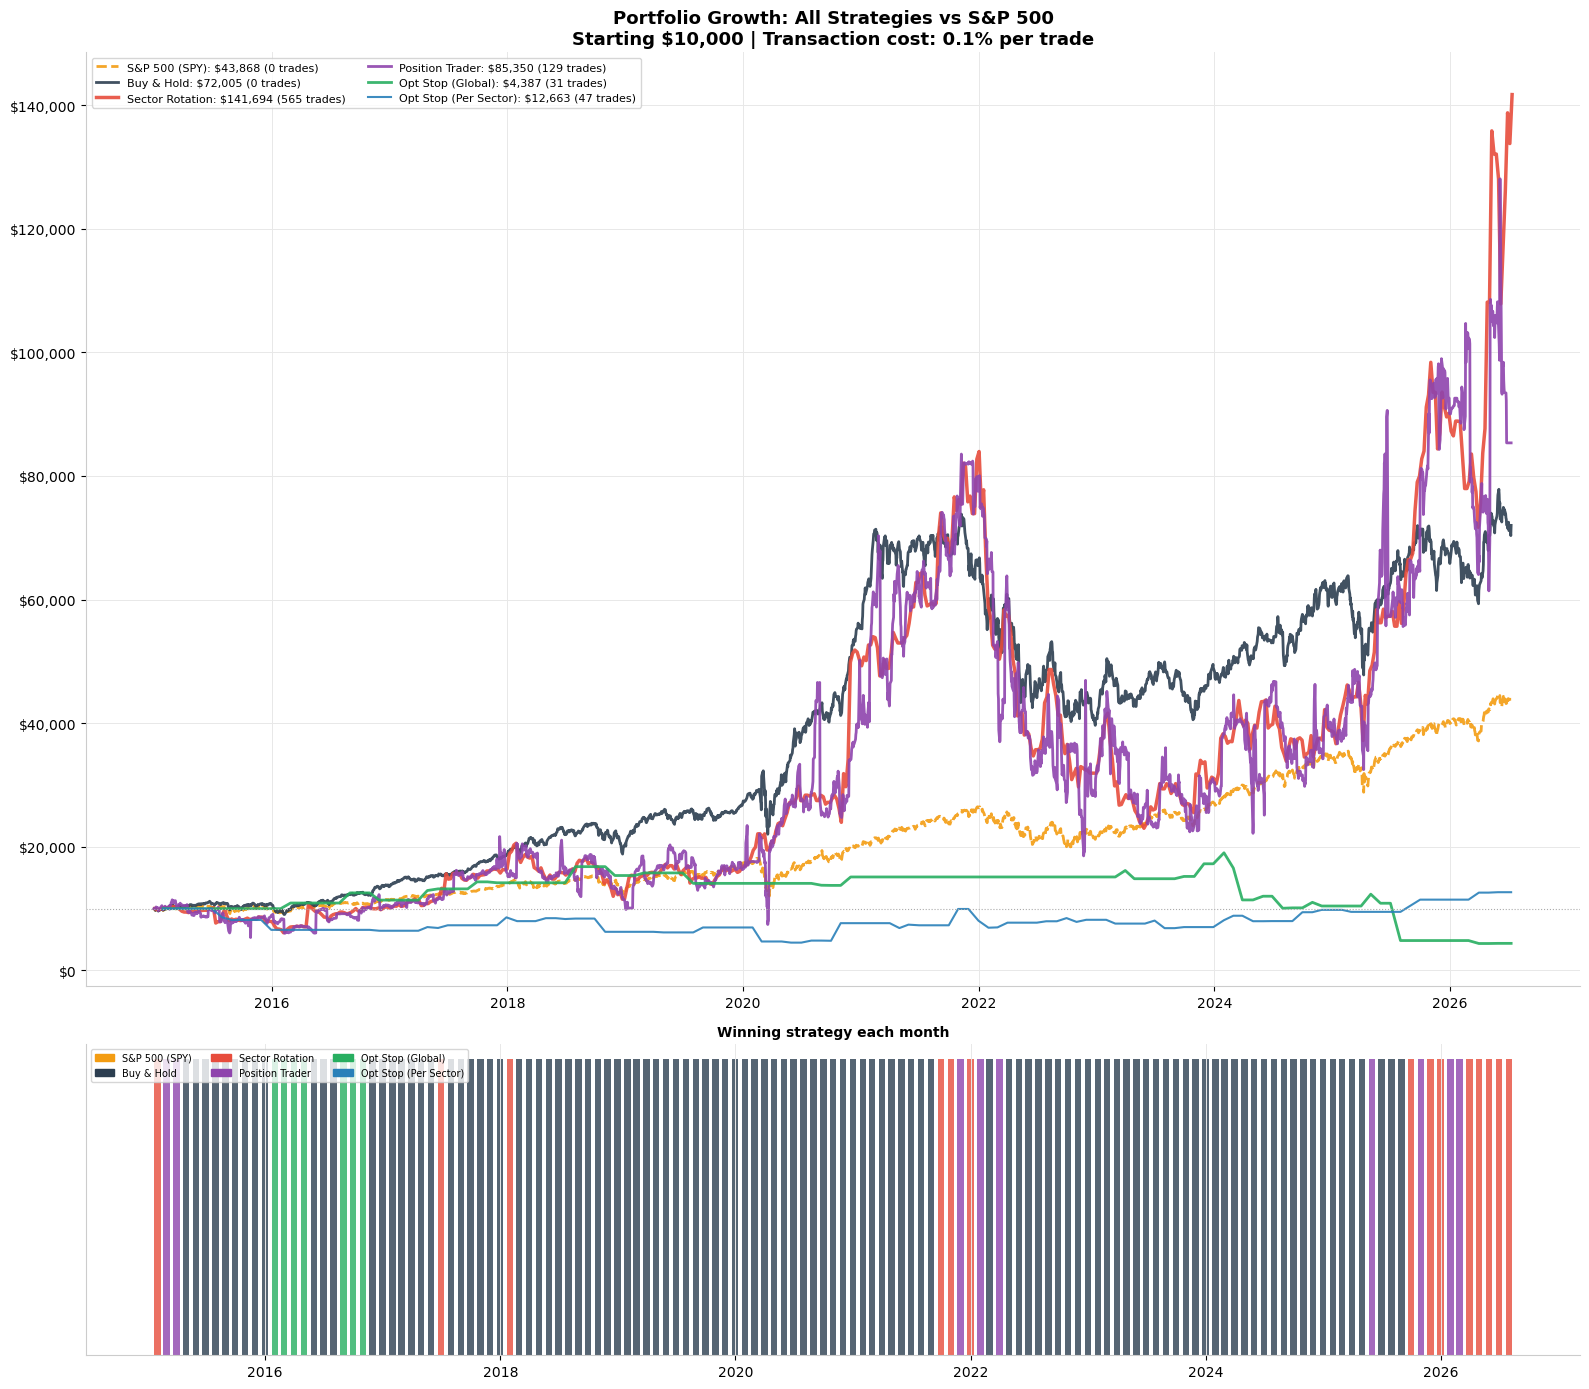


Transaction cost summary:
  Position trader : $8,334.65
  Opt stop global : $801.65
  Opt stop sector : $735.99
  Rotation        : ~$10.00 avg per trade


In [8]:
import matplotlib.colors as mcolors

strategies = {
    'S&P 500 (SPY)'        : (spy_dates,         spy_hist,         '#f39c12', '--', 2.0, 0),
    'Buy & Hold'           : (all_trading_dates, holdall_hist,     '#2c3e50', '-',  2.0, 0),
    'Sector Rotation'      : (rot_dates,         rot_hist,         '#e74c3c', '-',  2.5, rot_trades),
    'Position Trader'      : (pos_dates,         pos_hist,         '#8e44ad', '-',  2.0, n_trades),
    'Opt Stop (Global)'    : (opt_global_dates,  opt_global_hist,  '#27ae60', '-',  2.0, len(df_trades_global)),
    'Opt Stop (Per Sector)': (opt_sector_dates,  opt_sector_hist,  '#2980b9', '-',  1.5, len(df_trades_sector)),
}

fig, axes = plt.subplots(2, 1, figsize=(16, 14), facecolor='white',
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
for label, (dates, hist, color, ls, lw, n_tr) in strategies.items():
    if not dates or not hist: continue
    final = hist[-1]
    ax.plot(dates, hist, color=color, linestyle=ls, linewidth=lw,
            label=f'{label}: ${final:,.0f} ({n_tr} trades)', alpha=0.9)

# Gradient coloring: green when rotation beats SPY, red when it doesn't
spy_series = pd.Series(spy_hist, index=spy_dates)
rot_series = pd.Series(rot_hist, index=rot_dates)
common_idx = sorted(set(spy_series.index) & set(rot_series.index))
if common_idx:
    spy_aligned = spy_series.reindex(common_idx).interpolate('time')
    rot_aligned = rot_series.reindex(common_idx).interpolate('time')
    ax.fill_between(common_idx, spy_aligned, rot_aligned,
                    where=[r > s for r, s in zip(rot_aligned, spy_aligned)],
                    color='#a9dfbf', alpha=0.25, label='Rotation beating SPY')
    ax.fill_between(common_idx, spy_aligned, rot_aligned,
                    where=[r < s for r, s in zip(rot_aligned, spy_aligned)],
                    color='#f5b7b1', alpha=0.25, label='SPY beating rotation')

ax.axhline(STARTING_CASH, color='#aaaaaa', linewidth=0.8, linestyle=':')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title(f'Portfolio Growth: All Strategies vs S&P 500\nStarting ${STARTING_CASH:,} | Transaction cost: {TOTAL_COST_PER_TRADE:.1%} per trade',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_facecolor('white')

# Bottom panel: which strategy is winning each month
ax2 = axes[1]
strat_colors_map = {
    'S&P 500 (SPY)': '#f39c12', 'Buy & Hold': '#2c3e50',
    'Sector Rotation': '#e74c3c', 'Position Trader': '#8e44ad',
    'Opt Stop (Global)': '#27ae60', 'Opt Stop (Per Sector)': '#2980b9',
}
# Resample all to monthly and find winner
monthly_vals = {}
for label, (dates, hist, *_) in strategies.items():
    if dates and hist:
        s = pd.Series(hist, index=pd.to_datetime(dates)).resample('ME').last()
        monthly_vals[label] = s
df_monthly = pd.DataFrame(monthly_vals).dropna(how='all')
if not df_monthly.empty:
    winner_each_month = df_monthly.idxmax(axis=1)
    for i, (month, winner) in enumerate(winner_each_month.items()):
        c = strat_colors_map.get(winner, '#888888')
        ax2.bar(month, 1, width=20, color=c, alpha=0.8)
    ax2.set_yticks([])
    ax2.set_title('Winning strategy each month', fontsize=10, fontweight='bold')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    legend_patches = [mpatches.Patch(color=v, label=k) for k,v in strat_colors_map.items()]
    ax2.legend(handles=legend_patches, fontsize=7, loc='upper left', ncol=3, facecolor='white')
    ax2.set_facecolor('white')

plt.tight_layout()
plt.show()

print('\nTransaction cost summary:')
print(f'  Position trader : ${total_cost:,.2f}')
print(f'  Opt stop global : ${cost_global:,.2f}')
print(f'  Opt stop sector : ${cost_sector:,.2f}')
print(f'  Rotation        : ~${rot_trades * STARTING_CASH * TOTAL_COST_PER_TRADE / rot_trades:.2f} avg per trade' if rot_trades > 0 else '  Rotation: N/A')

---
## 8. Trade Log with Source Attribution

In [9]:
# Combine all trade logs
all_trade_logs = []
if not df_trades.empty:
    df_trades['strategy'] = 'Position Trader'
    all_trade_logs.append(df_trades)
if not df_trades_global.empty:
    df_trades_global['strategy'] = 'Opt Stop Global'
    all_trade_logs.append(df_trades_global[['ticker','entry_date','exit_date',
                                              'return_pct','portfolio_val','strategy']])
if not df_trades_sector.empty:
    df_trades_sector['strategy'] = 'Opt Stop Sector'
    all_trade_logs.append(df_trades_sector[['ticker','entry_date','exit_date',
                                              'return_pct','portfolio_val','strategy']])

if all_trade_logs:
    df_all_trades = pd.concat(all_trade_logs, ignore_index=True)
    df_all_trades['entry_date'] = pd.to_datetime(df_all_trades['entry_date'])

    # Add source attribution: what sentiment triggered the trade?
    def get_trigger_source(ticker, entry_date):
        try:
            yesterday = pd.Timestamp(entry_date) - pd.Timedelta(days=1)
            srow = sig_idx.loc[(ticker, yesterday)]
            return srow.get('sources_active', 'unknown'), srow.get(sig_col, np.nan)
        except KeyError:
            return 'unknown', np.nan

    df_all_trades[['trigger_source','trigger_sentiment']] = df_all_trades.apply(
        lambda r: pd.Series(get_trigger_source(r['ticker'], r['entry_date'])), axis=1
    )

    print(f'Total trades across all strategies: {len(df_all_trades)}')
    wins = (df_all_trades['return_pct'] > 0).sum()
    print(f'Overall win rate: {wins}/{len(df_all_trades)} ({wins/len(df_all_trades):.1%})')
    print(f'Avg return: {df_all_trades["return_pct"].mean():.2f}%')
    print()
    print(df_all_trades[['ticker','strategy','entry_date','exit_date',
                          'return_pct','trigger_source','trigger_sentiment']]
          .sort_values('entry_date')
          .to_string(index=False))

Total trades across all strategies: 207
Overall win rate: 111/207 (53.6%)
Avg return: 0.21%

ticker        strategy entry_date  exit_date  return_pct                        trigger_source  trigger_sentiment
   CRM Position Trader 2015-01-07 2015-02-06        3.93                                    hn           0.857850
  DSGR Position Trader 2015-02-13 2015-03-17        2.68                                    hn           1.100100
  META Position Trader 2015-03-17 2015-04-16        3.72                      reddit_investing           0.765900
   UAL Position Trader 2015-04-20 2015-05-19       -2.55                                    hn           0.836100
  FOSL Position Trader 2015-05-20 2015-06-19       -8.53                                    hn           0.541800
  AAPL Position Trader 2015-06-24 2015-07-24       -2.82                         reddit_stocks           0.756000
  TSLA Opt Stop Sector 2015-07-23 2015-08-21      -13.63                      reddit_investing           0.15

---
## 9. Save Outputs

In [10]:
if GITHUB_TOKEN is None:
    print('GITHUB_TOKEN not set')
else:
    # Save equity curves
    curves = {}
    for label, (dates, hist, *_) in strategies.items():
        if dates and hist:
            curves[label.replace(' ','_').replace('/','_').replace('(','').replace(')','')] = \
                pd.Series(hist, index=pd.to_datetime(dates))
    df_curves = pd.DataFrame(curves)
    push_csv(df_curves.reset_index().rename(columns={'index':'date'}),
             f'{STRAT_PREFIX}/equity_curves.csv', GITHUB_TOKEN,
             f'Equity curves: {len(df_curves)} dates')

    if all_trade_logs:
        push_csv(df_all_trades, f'{STRAT_PREFIX}/trade_log.csv', GITHUB_TOKEN,
                 f'Trade log: {len(df_all_trades)} trades')

    print('Strategy outputs saved')

GITHUB_TOKEN not set


---
## 10. Per-Sector Backtests

The strategies above allocate across the whole universe, which produces a single
portfolio-level curve that cannot be broken down by sector after the fact.

This section re-runs the backtest separately for each sector so the dashboard's
sector filter has real data to show. For each sector it computes:

- **Buy & Hold** — equal weight across that sector's tickers
- **Position Trader** — 21-day holds triggered by sentiment, restricted to that sector
- **S&P 500 (SPY)** — the same benchmark, repeated per sector for comparison

Saves to `strategy_outputs/equity_curves_by_sector.csv` in long format
with columns: `date`, `sector`, `strategy`, `value`.

In [11]:
print('Running per-sector backtests ...')

sector_rows = []

# Shared SPY benchmark series
spy_curve = {}
if SPY_AVAILABLE:
    cash = STARTING_CASH
    for d in all_trading_dates:
        if d in df_spy.index:
            rr = df_spy.loc[d, 'daily_return']
            if not pd.isna(rr):
                cash *= (1 + rr)
        spy_curve[d] = cash

for sector_name, sector_tickers in SECTORS.items():
    tickers_avail = [t for t in sector_tickers
                     if t in price_cache and t not in TRADE_BLOCKLIST]
    if not tickers_avail:
        print(f'  {sector_name}: no tradeable tickers, skipped')
        continue

    # ── Buy & hold, equal weight within the sector ──────────────────────
    bh_cash = STARTING_CASH
    for d in all_trading_dates:
        rets = [price_cache[t].loc[d, 'daily_return']
                for t in tickers_avail if d in price_cache[t].index]
        rets = [x for x in rets if not pd.isna(x)]
        if rets:
            bh_cash *= (1 + float(np.mean(rets)))
        sector_rows.append({'date': d, 'sector': sector_name,
                            'strategy': 'Buy & Hold', 'value': bh_cash})

    # ── Position trader restricted to this sector ───────────────────────
    pt_cash      = STARTING_CASH
    in_pos       = False
    pos_end      = None
    pos_ticker   = None
    n_sector_trades = 0

    for d in all_trading_dates:
        if in_pos and pos_end is not None and d >= pos_end:
            in_pos = False
            n_sector_trades += 1

        if in_pos and pos_ticker in price_cache and d in price_cache[pos_ticker].index:
            rr = price_cache[pos_ticker].loc[d, 'daily_return']
            if not pd.isna(rr):
                pt_cash *= (1 + rr)
        elif not in_pos:
            yesterday = d - pd.Timedelta(days=1)
            best_sv, best_t = -999, None
            for t in tickers_avail:
                try:
                    srow = sig_idx.loc[(t, yesterday)]
                    sv = srow.get(sig_col, np.nan)
                    sc = srow.get('story_count', 0)
                    if not pd.isna(sv) and sv >= SENT_THRESHOLD and sc >= MIN_STORIES and sv > best_sv:
                        best_sv, best_t = sv, t
                except KeyError:
                    pass
            if best_t and d in price_cache[best_t].index:
                in_pos     = True
                pos_ticker = best_t
                future     = [x for x in all_trading_dates if x > d]
                pos_end    = future[HOLD_DAYS - 1] if len(future) >= HOLD_DAYS else (future[-1] if future else None)
                pt_cash   -= pt_cash * TOTAL_COST_PER_TRADE

        sector_rows.append({'date': d, 'sector': sector_name,
                            'strategy': 'Position Trader', 'value': pt_cash})

    # ── SPY benchmark repeated for this sector ──────────────────────────
    for d in all_trading_dates:
        if d in spy_curve:
            sector_rows.append({'date': d, 'sector': sector_name,
                                'strategy': 'S&P 500 (SPY)', 'value': spy_curve[d]})

    print(f'  {sector_name:22s} {len(tickers_avail)} tickers | '
          f'Buy&Hold ${bh_cash:,.0f} | Position ${pt_cash:,.0f} ({n_sector_trades} trades)')

df_sector_curves = pd.DataFrame(sector_rows)
print(f'\nPer-sector curves: {len(df_sector_curves):,} rows across '
      f'{df_sector_curves["sector"].nunique()} sectors')

if GITHUB_TOKEN:
    # Saved in long format so the dashboard can filter by sector
    push_csv(df_sector_curves, f'{STRAT_PREFIX}/equity_curves_by_sector.csv', GITHUB_TOKEN,
             f'Per-sector equity curves: {len(df_sector_curves):,} rows')

    summary = (df_sector_curves.sort_values('date')
               .groupby(['sector','strategy'])['value'].last()
               .unstack()
               .round(0))
    print('\nFinal value by sector:')
    print(summary.to_string())

Running per-sector backtests ...
  AI Accelerators        1 tickers | Buy&Hold $2,021,375 | Position $45,147 (51 trades)
  Semiconductor Supply   3 tickers | Buy&Hold $103,835 | Position $73,206 (60 trades)
  Big Tech               4 tickers | Buy&Hold $131,306 | Position $20,085 (91 trades)
  Cloud / SaaS           4 tickers | Buy&Hold $199,542 | Position $5,636 (75 trades)
  Cybersecurity          3 tickers | Buy&Hold $184,222 | Position $15,722 (19 trades)
  Enterprise AI          1 tickers | Buy&Hold $112,916 | Position $12,796 (20 trades)
  Macro Risk             2 tickers | Buy&Hold $197,388 | Position $41,434 (53 trades)
  Portfolio              2 tickers | Buy&Hold $27,590 | Position $9,032 (12 trades)
  Consumer Tech          1 tickers | Buy&Hold $145,283 | Position $13,669 (40 trades)
  Enterprise Fintech     1 tickers | Buy&Hold $11,645 | Position $4,534 (36 trades)

Per-sector curves: 86,850 rows across 10 sectors
